# Electricity Price Analysis v2 (concise)

Simple, leakage-safe baseline model and distributional comparison (QQ + Wasserstein).

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance, cauchy, norm, levy_stable
from distribution_fitting import DistributionFitter, DistributionQuantiles, plot_quantile_qq

sns.set(style="whitegrid")

In [31]:
# Load data (compact)
train = pd.read_csv('data/nsw_training_data.csv').rename(columns={'value': 'price'})[['timestamp','price']].copy()
test = pd.read_csv('data/nsw_testing_data.csv').rename(columns={'value': 'price'})[['timestamp','price']].copy()
# ensure datetime and sort
train['timestamp'] = pd.to_datetime(train['timestamp'])
test['timestamp'] = pd.to_datetime(test['timestamp'])
train = train.sort_values('timestamp').reset_index(drop=True)
test = test.sort_values('timestamp').reset_index(drop=True)
print(f"Train: {len(train)} rows, Test: {len(test)} rows")

Train: 8758 rows, Test: 744 rows


In [32]:
# -----------------------------
# Model helpers (no leakage)
# -----------------------------
def compute_shifted_monthly_median(series, lag_hours=30*24):
    # rolling median computed over past window only by shifting the result
    return series.rolling(window=lag_hours, min_periods=1).median().shift(1)

def fit_simple_model(train_prices, lag_hours=30*24):
    # compute shifted monthly median (based only on past data)
    mm = compute_shifted_monthly_median(train_prices, lag_hours=lag_hours)
    # previous price
    p_prev = train_prices.shift(1)
    # Y uses only past-month-median (shifted) and previous price -> no leakage
    Y = (train_prices - p_prev) / (mm - p_prev)
    median_Y = Y.dropna().median()
    return float(median_Y)

def apply_simple_model(all_prices, median_Y, lag_hours=30*24):
    mm = compute_shifted_monthly_median(all_prices, lag_hours=lag_hours)
    p_prev = all_prices.shift(1)  
    Y = (all_prices - p_prev) / (mm - p_prev)
    pred = p_prev + median_Y * (mm - p_prev)
    return pred, median_Y * (mm - p_prev), Y

In [33]:
# Train model and apply to combined data
lag = 30*24
combined = pd.concat([train.assign(split='train'), test.assign(split='test')]).sort_values('timestamp').reset_index(drop=True)
median_Y = fit_simple_model(combined[combined.split=='train'].price, lag_hours=lag)

pred, reversion, Y = apply_simple_model(combined.price, median_Y, lag_hours=lag)
combined['Y'] = Y
combined['pred'] = pred
combined['reversion'] = reversion 
combined['error'] = combined['Y'] / median_Y #combined['price'] - combined['pred']
print(f"median_Y (train): {median_Y:.6f}")
train_valid = combined[(combined.split=='train') & (combined.pred.notna())].copy()
test_valid = combined[(combined.split=='test') & (combined.pred.notna())].copy()
print(f"Train valid: {len(train_valid)}, Test valid: {len(test_valid)}")

median_Y (train): 0.067634
Train valid: 8757, Test valid: 744


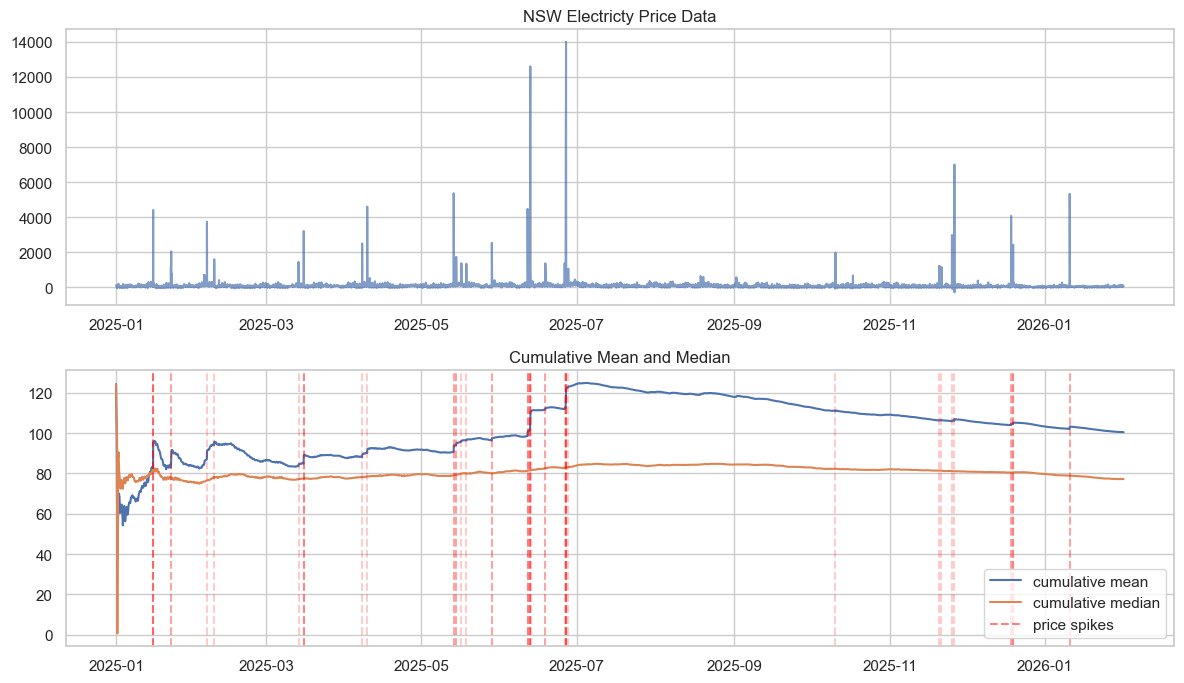

In [34]:
# -----------------------------
# Plots: price, cumulative mean & median
# -----------------------------
fig, ax = plt.subplots(2, 1,figsize=(12,7))
ax[0].plot(combined.timestamp, combined.price, label='price', alpha=0.7)
# plt.plot(combined.timestamp, combined.pred, label='pred', alpha=0.7)
# ax[0].legend()
ax[0].set_title('NSW Electricty Price Data')
# plt.show()

# cumulative statistics (use training portion to illustrate learning behaviour)
cum = combined.copy()
cum['cum_mean'] = cum.price.expanding().mean()
cum['cum_median'] = cum.price.expanding().median()
outliers = 1*(combined.price > np.quantile(combined.price, [0.995]).item())
outlier_loc = [combined.timestamp[i] for i, o in enumerate(outliers) if o > 0]
ax[1].plot(cum.timestamp, cum.cum_mean, label='cumulative mean')
ax[1].plot(cum.timestamp, cum.cum_median, label='cumulative median')
for loc in outlier_loc:
    ax[1].axvline(loc, c='red', linestyle='--', alpha = 0.2)
ax[1].axvline(outlier_loc[0], c='red', linestyle='--', label='price spikes',alpha = 0.5)
ax[1].legend()
ax[1].set_title('Cumulative Mean and Median')
plt.tight_layout()
plt.show()

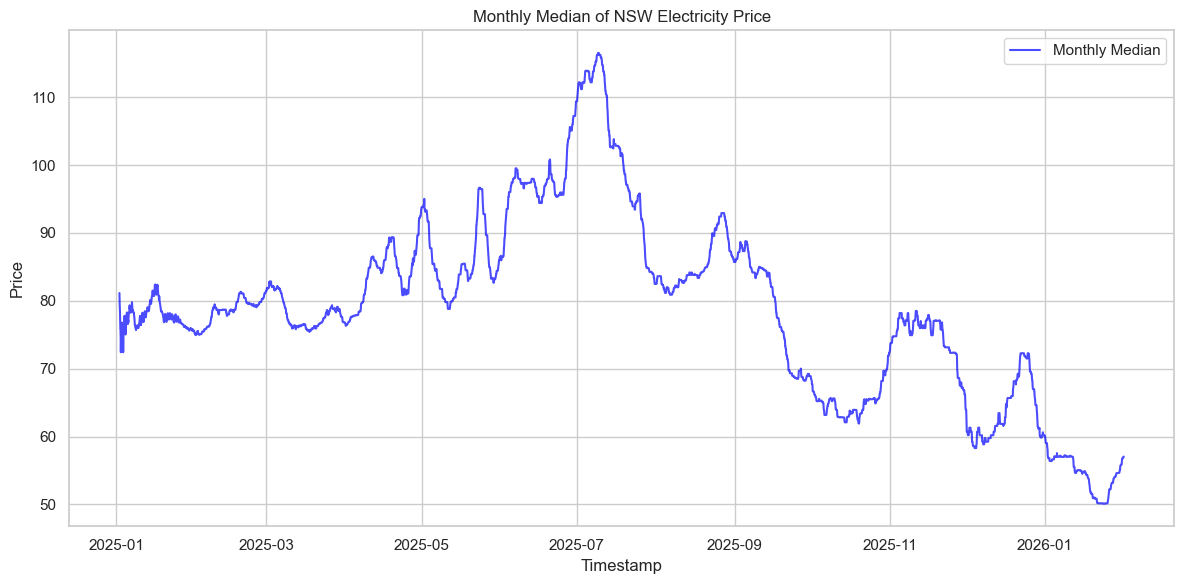

: 

: 

: 

: 

In [ ]:
# Plot the monthly median of price
monthly_median = compute_shifted_monthly_median(combined.price, lag_hours=30*24)

plt.figure(figsize=(12, 6))
plt.plot(combined.timestamp[30:], monthly_median[30:], label='Monthly Median', color='blue',alpha=0.7)
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.title('Monthly Median of NSW Electricity Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
# -----------------------------
# Fit candidate distributions to training errors
# -----------------------------
errors_train = train_valid.error.replace([np.inf, -np.inf], np.nan).dropna().values
fitter = DistributionFitter()
# Gaussian (all data)
dist_gauss_all = fitter.fit(errors_train, 'gaussian')
dist_gauss_all.name = 'Gaussian (All Data)'
# Gaussian (filtered: remove outliers > 3 std devs)
# mean = errors_train.mean()
# std = errors_train.std()
# mask = (errors_train >= mean - 3*std) & (errors_train <= mean + 3*std)
# errors_train_filtered = errors_train[mask]
dist_gauss_filtered = fitter.fit(errors_train, 'gaussian')
dist_gauss_filtered.name = 'Gaussian (Quantile Estimated-Parameters)'
dist_gauss_filtered.params['mu'] = np.median(errors_train)
q25, q75 = np.quantile(errors_train, [0.25, 0.75])
dist_gauss_filtered.params['sigma'] = (q75 - q25) / 2
# Cauchy
dist_cauch = fitter.fit(errors_train, 'cauchy')
dist_cauch.params['loc'] = np.median(errors_train)
q25, q75 = np.quantile(errors_train, [0.25, 0.75])
dist_cauch.params['scale'] = (q75 - q25) / 2
# Levy
dist_levy = fitter.fit(errors_train, 'levy')
dist_levy.params['loc'] = np.median(errors_train)
dist_levy.params['scale'] = (q75 - q25) / 2
# Update distributions list
distributions = [dist_gauss_all, dist_gauss_filtered, dist_cauch, dist_levy]
for d in distributions:
    print(d.name, d.params)

Gaussian (All Data) {'mu': np.float64(-3.503143734334373), 'sigma': np.float64(911.5969611846035)}
Gaussian (Quantile Estimated-Parameters) {'mu': np.float64(1.0), 'sigma': np.float64(5.233650204024748)}
Cauchy {'loc': np.float64(1.0), 'scale': np.float64(5.233650204024748)}
Levy Stable {'alpha': np.float64(0.9145395940248542), 'beta': np.float64(-0.02686486327469727), 'loc': np.float64(1.0), 'scale': np.float64(5.233650204024748)}


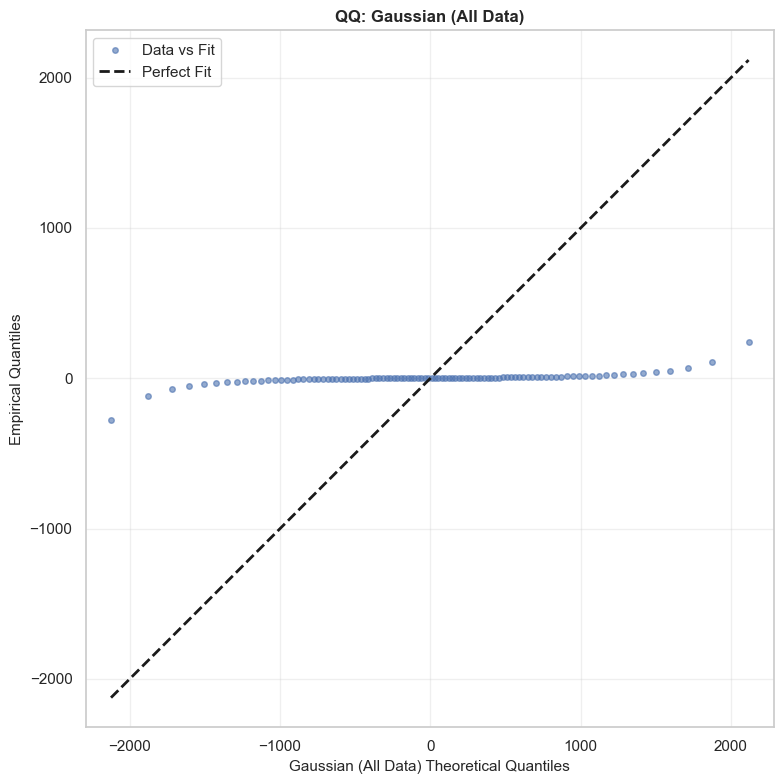

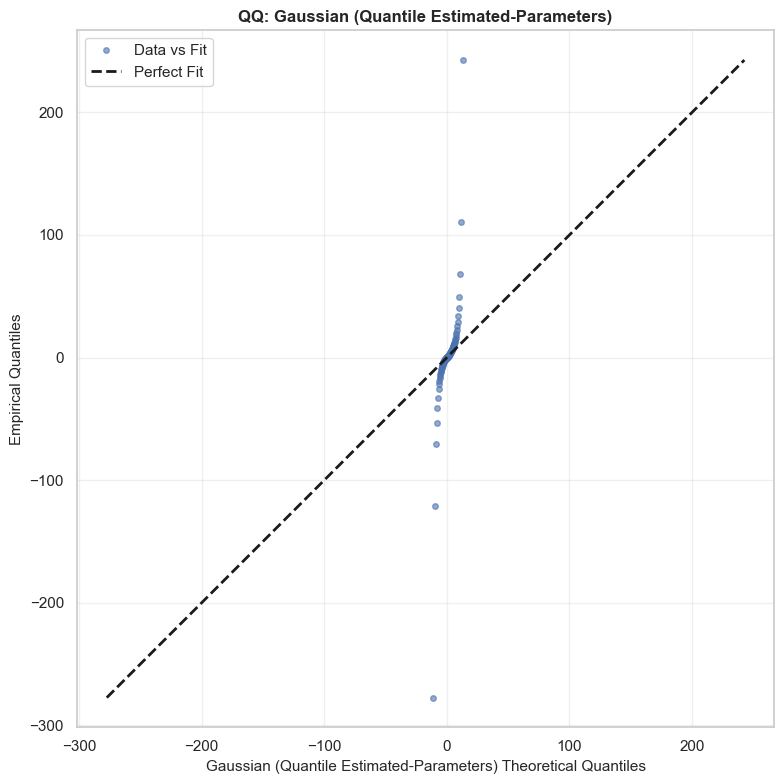

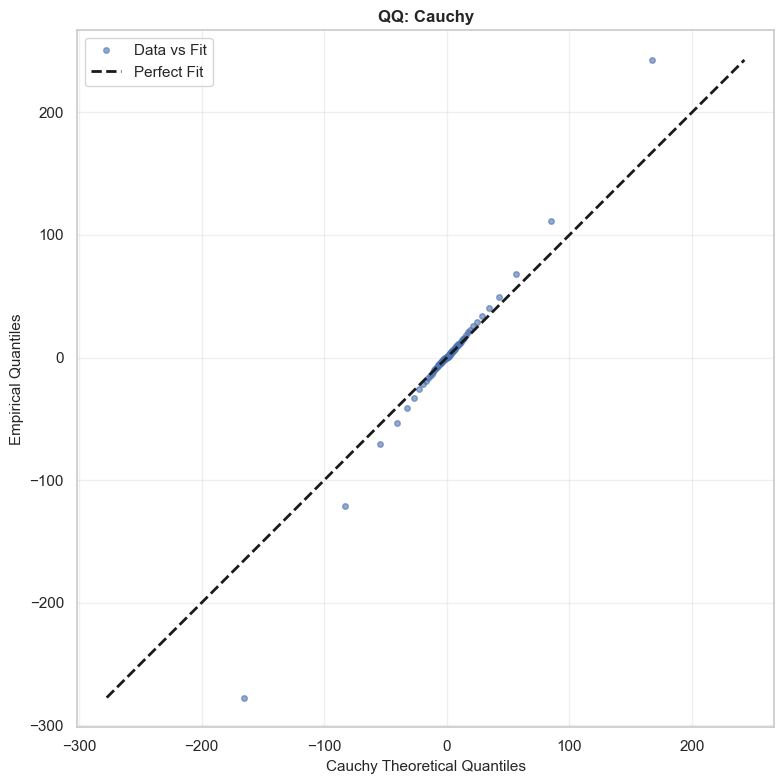

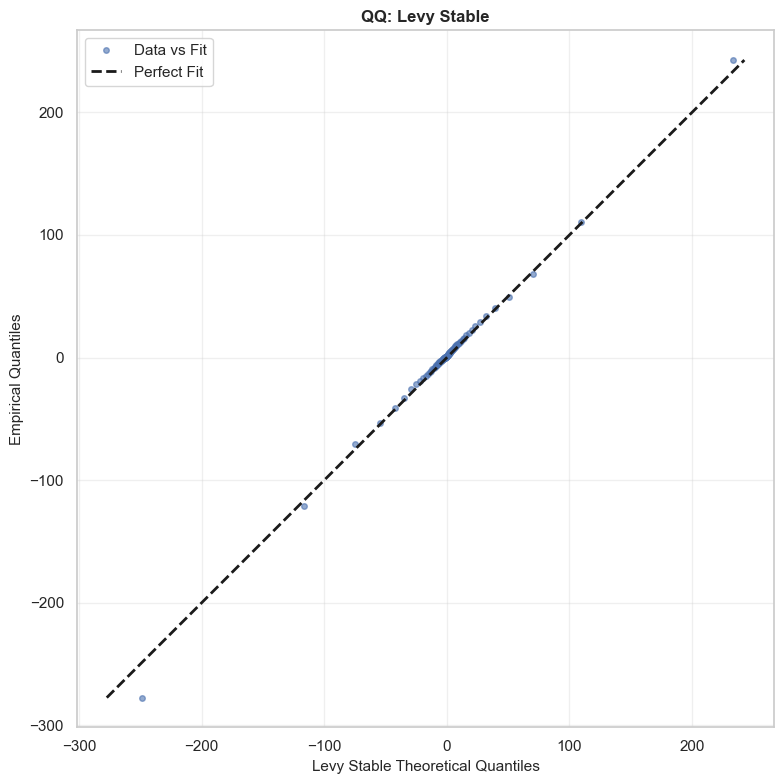

                            distribution  wasserstein
                             Levy Stable    56.873610
                                  Cauchy    56.902467
Gaussian (Quantile Estimated-Parameters)    56.948891
                     Gaussian (All Data)   719.401644


In [36]:
# -----------------------------
# QQ-plots and Wasserstein distances
# -----------------------------
n = len(errors_train)
results = []
for d in distributions:
    # generate synthetic sample from fitted params (fallback to scipy when possible)
    params = d.params
    if d.name.lower().startswith('gaussian') or 'mu' in params or 'loc' in params:
        mu = params.get('mu', params.get('loc', 0.0))
        sigma = params.get('sigma', params.get('scale', np.std(errors_train)))
        synth = np.random.normal(loc=mu, scale=sigma, size=n)
    elif d.name.lower().startswith('cauch'):
        loc = params.get('loc', 0.0)
        scale = params.get('scale', 1.0)
        synth = cauchy.rvs(loc=loc, scale=scale, size=n)
    else:
        # levy stable: expect keys 'alpha','beta','loc','scale' in params
        alpha = params.get('alpha', 1.7)
        beta = params.get('beta', 0.0)
        loc = params.get('loc', 0.0)
        scale = params.get('scale', np.std(errors_train))
        synth = levy_stable.rvs(alpha, beta, loc=loc, scale=scale, size=n)

    # QQ plot (uses helper)
    try:
        plot_quantile_qq(d, errors_train, title=f"QQ: {d.name}")
    except Exception:
        # fallback: scipy probplot against normal for visibility
        stats.probplot(errors_train, plot=plt)
        plt.title(f"QQ fallback: {d.name}")
        plt.show()

    w = wasserstein_distance(errors_train, synth)
    results.append({'distribution': d.name, 'wasserstein': w})

res_df = pd.DataFrame(results).sort_values('wasserstein')
print(res_df.to_string(index=False))

In [ ]:
Q = [i/10 for i in range(1, 10)]
dist_quantiles = {d.name:[] for d in distributions}
dist_quantiles['actual'] = np.quantile(train_valid.error, Q)
for d in distributions:
    quantiles = DistributionQuantiles.get_quantiles(d,Q)
    dist_quantiles[d.name] = quantiles

pd.DataFrame.from_dict(dist_quantiles, orient = 'index', columns = Q)

,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
Gaussian (All Data),-1171.761656,-770.722503,-481.545058,-234.453593,-3.503144,227.447306,474.538770,763.716215,1164.755369
Gaussian (Filtered),-5.707193,-3.404751,-1.744529,-0.325930,1.000000,2.325930,3.744529,5.404751,7.707193
Cauchy,-15.107519,-6.203502,-2.802469,-0.700516,1.000000,2.700516,4.802469,8.203502,17.107519
Levy Stable,-18.975278,-7.816191,-3.949960,-1.755840,-0.091320,1.536641,3.610379,7.211333,17.611079
actual,-16.503880,-5.565742,-1.775928,-0.140075,1.000000,2.999493,5.506829,9.486382,20.272530


: 

In [37]:
Q = [i/10 for i in range(1, 10)]
dist_quantiles = {d.name:[] for d in distributions}
dist_quantiles['actual'] = np.quantile(test_valid.error, Q)
for d in distributions:
    quantiles = DistributionQuantiles.get_quantiles(d,Q)
    dist_quantiles[d.name] = quantiles

pd.DataFrame.from_dict(dist_quantiles, orient = 'index', columns = Q)

,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
Gaussian (All Data),-1171.761656,-770.722503,-481.545058,-234.453593,-3.503144,227.447306,474.538770,763.716215,1164.755369
Gaussian (Quantile Estimated-Parameters),-5.707193,-3.404751,-1.744529,-0.325930,1.000000,2.325930,3.744529,5.404751,7.707193
Cauchy,-15.107519,-6.203502,-2.802469,-0.700516,1.000000,2.700516,4.802469,8.203502,17.107519
Levy Stable,-18.975278,-7.816191,-3.949960,-1.755840,-0.091320,1.536641,3.610379,7.211333,17.611079
actual,-15.997832,-6.245191,-2.562404,-0.503481,1.015739,2.711462,4.807018,8.088907,17.546085


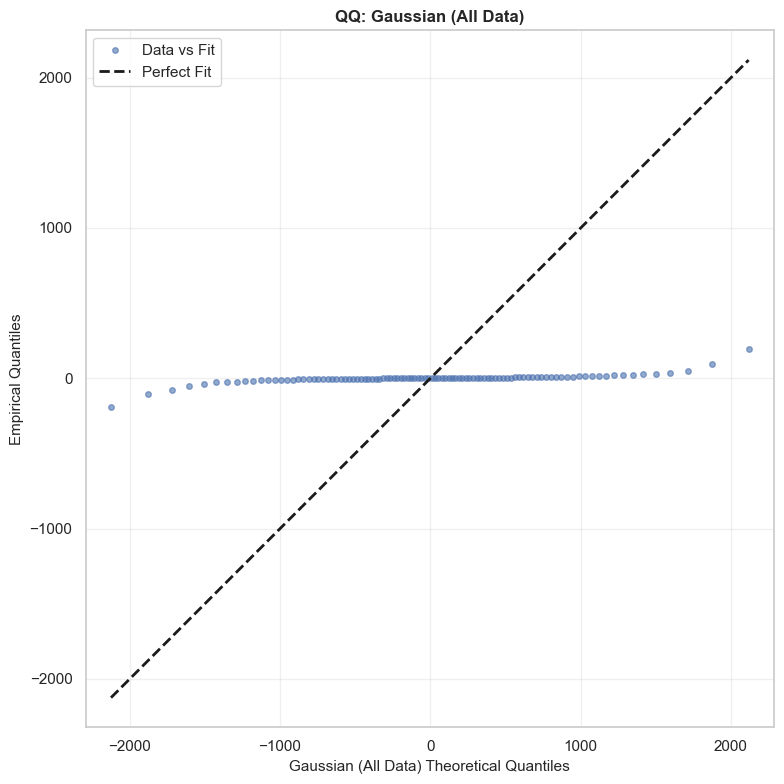

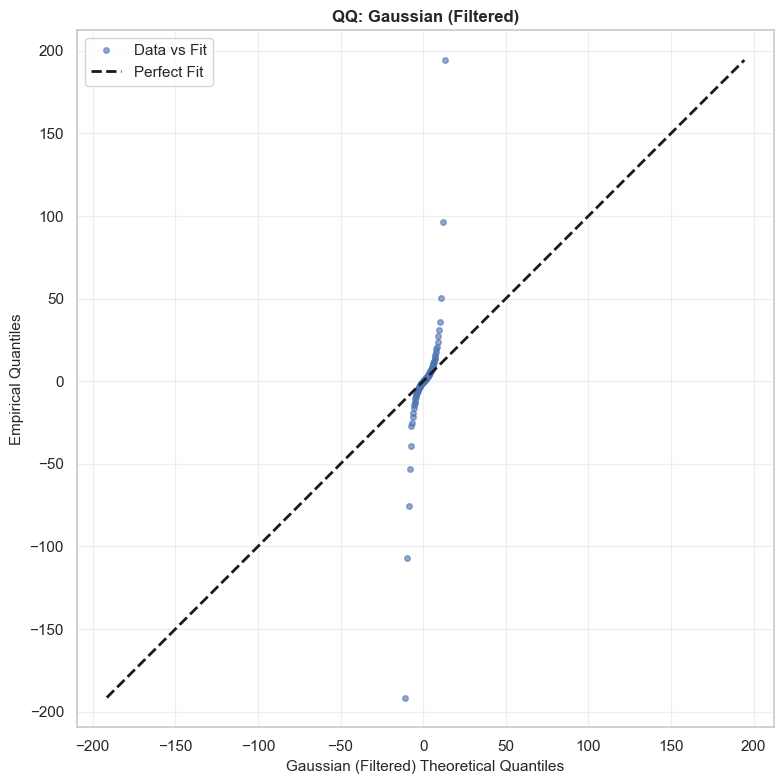

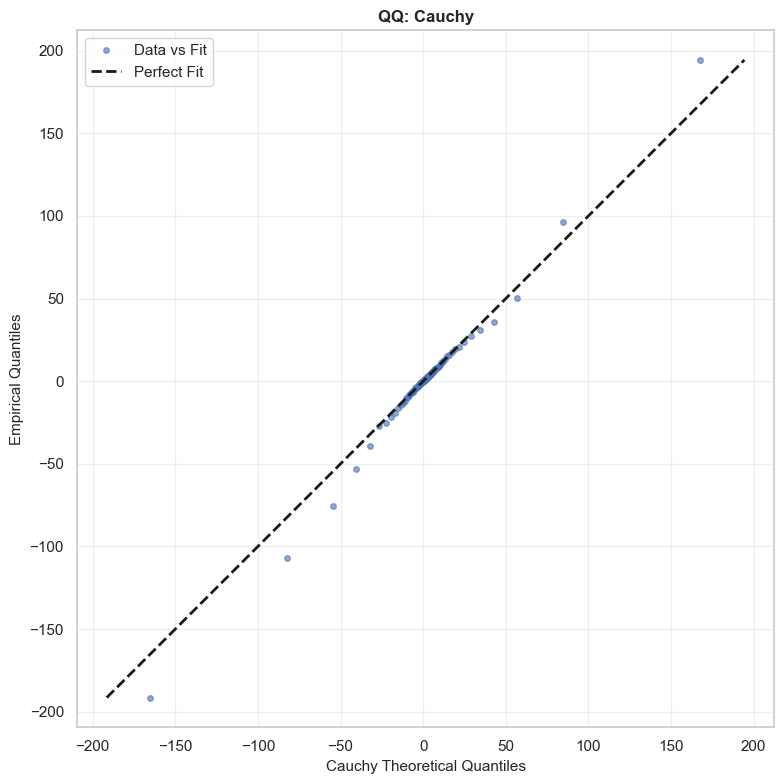

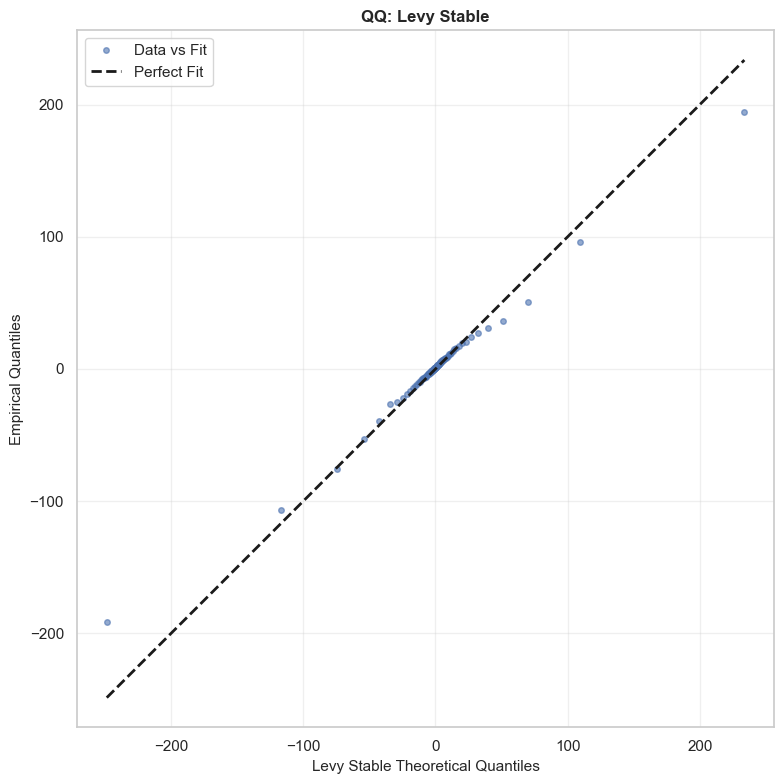

       distribution  wasserstein
Gaussian (Filtered)   216.774377
        Levy Stable   216.917858
             Cauchy   216.935253
Gaussian (All Data)   853.621664


In [24]:
# -----------------------------
# QQ-plots and Wasserstein distances (Test Data)
# -----------------------------
errors_test = test_valid.error.replace([np.inf, -np.inf], np.nan).dropna().values


n = len(errors_test)
results = []
for d in distributions:
    # generate synthetic sample from fitted params (fallback to scipy when possible)
    params = d.params
    if d.name.lower().startswith('gaussian') or 'mu' in params or 'loc' in params:
        mu = params.get('mu', params.get('loc', 0.0))
        sigma = params.get('sigma', params.get('scale', np.std(errors_test)))
        synth = np.random.normal(loc=mu, scale=sigma, size=n)
    elif d.name.lower().startswith('cauch'):
        loc = params.get('loc', 0.0)
        scale = params.get('scale', 1.0)
        synth = cauchy.rvs(loc=loc, scale=scale, size=n)
    else:
        # levy stable: expect keys 'alpha','beta','loc','scale' in params
        alpha = params.get('alpha', 1.7)
        beta = params.get('beta', 0.0)
        loc = params.get('loc', 0.0)
        scale = params.get('scale', np.std(errors_test))
        synth = levy_stable.rvs(alpha, beta, loc=loc, scale=scale, size=n)

    # QQ plot (uses helper)
    try:
        plot_quantile_qq(d, errors_test, title=f"QQ: {d.name}")
    except Exception:
        # fallback: scipy probplot against normal for visibility
        stats.probplot(errors_test, plot=plt)
        plt.title(f"QQ fallback: {d.name}")
        plt.show()

    w = wasserstein_distance(errors_test, synth)
    results.append({'distribution': d.name, 'wasserstein': w})

res_df = pd.DataFrame(results).sort_values('wasserstein')
print(res_df.to_string(index=False))


In [51]:
# For each fitted distribution, compute proportion of predictions within IQR and 95% ribbons (train & test)
Q = [0.025, 0.25, 0.75, 0.975]
results = []
for d in distributions:
    q_offsets = np.array(DistributionQuantiles.get_quantiles(d, Q))

    for split_name, df in [('Train', train_valid), ('Test', test_valid)]:
        sel = df[['pred','reversion','price']].dropna()
        preds = sel.pred.values
        rev = sel.reversion.values
        actuals = sel.price.values
        if len(preds) == 0:
            iqr_prop = np.nan
            p95_prop = np.nan
        else:
            ribbons = preds[:, None] + rev[:, None] * q_offsets  # shape (n,4)
            low_iqr = np.minimum(ribbons[:,1], ribbons[:,2])
            up_iqr  = np.maximum(ribbons[:,1], ribbons[:,2])
            low_95  = np.minimum(ribbons[:,0], ribbons[:,3])
            up_95   = np.maximum(ribbons[:,0], ribbons[:,3])

            in_iqr = (actuals >= low_iqr) & (actuals <= up_iqr)
            in_95  = (actuals >= low_95) & (actuals <= up_95)

            iqr_prop = in_iqr.mean()
            p95_prop = in_95.mean()

        results.append({
            'distribution': d.name,
            'split': split_name,
            'prop_in_iqr': iqr_prop,
            'prop_in_95': p95_prop,
            'n': len(preds)
        })

pd.DataFrame(results).pivot(index='distribution', columns='split', values=['prop_in_iqr','prop_in_95','n'])

prop_in_iqr           prop_in_95  \
split                                           Test     Train       Test   
distribution                                                                
Cauchy                                      0.500000  0.499144   0.938172   
Gaussian (All Data)                         0.989247  0.990979   0.993280   
Gaussian (Quantile Estimated-Parameters)    0.388441  0.388375   0.701613   
Levy Stable                                 0.506720  0.497545   0.950269   

                                                        n          
split                                        Train   Test   Train  
distribution                                                       
Cauchy                                    0.937536  744.0  8757.0  
Gaussian (All Data)                       0.995889  744.0  8757.0  
Gaussian (Quantile Estimated-Parameters)  0.682654  744.0  8757.0  
Levy Stable                               0.950097  744.0  8757.0

In [26]:
# For each fitted distribution, compute proportion of predictions within IQR and 95% ribbons (train & test)
Q = [0.025, 0.25, 0.75, 0.975]
results = []
for d in distributions:
    q_offsets = np.array(DistributionQuantiles.get_quantiles(d, Q))

    for split_name, df in [('Train', train_valid), ('Test', test_valid)]:
        sel = df[['pred','reversion','price']].dropna()
        preds = sel.pred.values
        rev = sel.reversion.values
        actuals = sel.price.values
        outlier_actuals_mask = (actuals > np.quantile(actuals, 0.99))
        if len(preds) == 0:
            iqr_prop = np.nan
            p95_prop = np.nan
        else:
            ribbons = preds[:, None] + rev[:, None] * q_offsets  # shape (n,4)
            low_iqr = np.minimum(ribbons[:,1], ribbons[:,2])
            up_iqr  = np.maximum(ribbons[:,1], ribbons[:,2])
            low_95  = np.minimum(ribbons[:,0], ribbons[:,3])
            up_95   = np.maximum(ribbons[:,0], ribbons[:,3])

            in_iqr = (actuals >= low_iqr) & (actuals <= up_iqr)
            in_95  = (actuals >= low_95) & (actuals <= up_95)

            iqr_prop = in_iqr[outlier_actuals_mask].mean()
            p95_prop = in_95[outlier_actuals_mask].mean()

        results.append({
            'distribution': d.name,
            'split': split_name,
            'prop_in_iqr': iqr_prop,
            'prop_in_95': p95_prop,
            'n': len(preds[outlier_actuals_mask])
        })

pd.DataFrame(results).pivot(index='distribution', columns='split', values=['prop_in_iqr','prop_in_95','n'])

prop_in_iqr           prop_in_95              n      
split                      Test     Train       Test     Train Test Train
distribution                                                             
Cauchy                    0.250  0.250000      0.750  0.613636  8.0  88.0
Gaussian (All Data)       1.000  0.897727      1.000  0.931818  8.0  88.0
Gaussian (Filtered)       0.125  0.170455      0.500  0.454545  8.0  88.0
Levy Stable               0.125  0.272727      0.875  0.670455  8.0  88.0

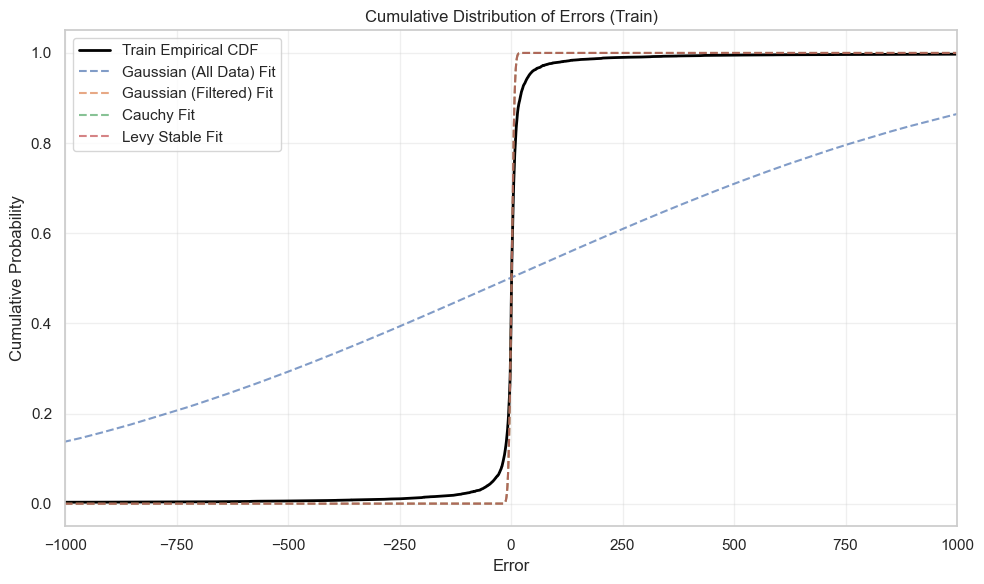

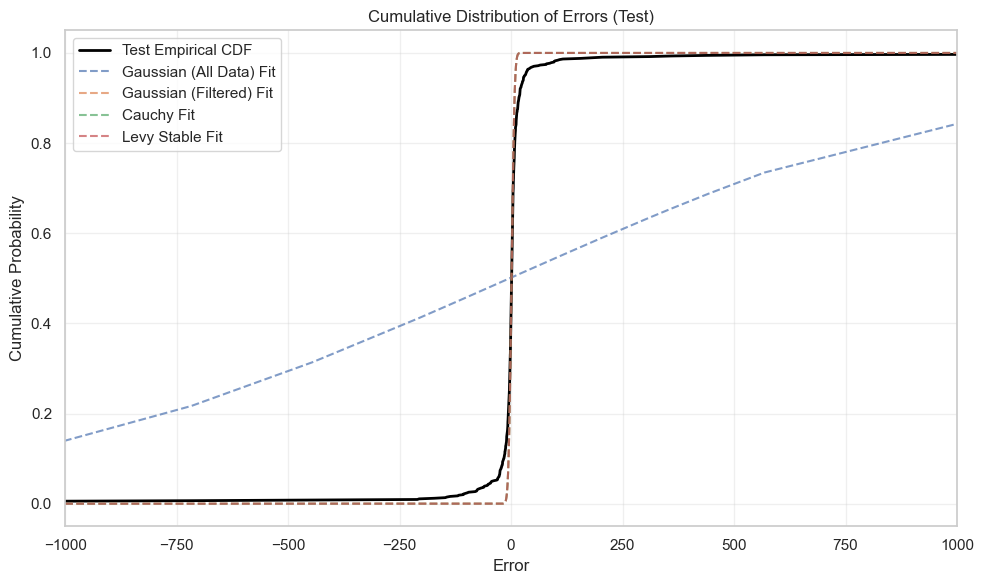

In [27]:
# Plot cumulative distribution of errors and fitted distributions for train and test
import matplotlib.pyplot as plt
for split, errors in [('Train', errors_train), ('Test', test_valid.error.dropna().values)]:
    plt.figure(figsize=(10,6))
    # Empirical CDF
    sorted_errors = np.sort(errors)
    cdf_emp = np.arange(1, len(errors)+1) / len(errors)
    plt.plot(sorted_errors, cdf_emp, label=f'{split} Empirical CDF', color='black', linewidth=2)
    # Fitted distributions
    for d in distributions:
        params = d.params
        if d.name.lower().startswith('gaussian') or 'mu' in params or 'loc' in params:
            mu = params.get('mu', params.get('loc', 0.0))
            sigma = params.get('sigma', params.get('scale', errors.std()))
            cdf_fit = stats.norm.cdf(sorted_errors, loc=mu, scale=sigma)
        elif d.name.lower().startswith('cauch'):
            loc = params.get('loc', 0.0)
            scale = params.get('scale', 1.0)
            cdf_fit = stats.cauchy.cdf(sorted_errors, loc=loc, scale=scale)
        else:
            alpha = params.get('alpha', 1.7)
            beta = params.get('beta', 0.0)
            loc = params.get('loc', 0.0)
            scale = params.get('scale', errors.std())
            cdf_fit = levy_stable.cdf(sorted_errors, alpha, beta, loc=loc, scale=scale)
        plt.plot(sorted_errors, cdf_fit, label=f'{d.name} Fit', linestyle='--', alpha = 0.7)
    plt.title(f'Cumulative Distribution of Errors ({split})')
    plt.xlabel('Error')
    plt.ylabel('Cumulative Probability')
    plt.xlim(-1000, 1000)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
import importlib
import ribbon_plot
importlib.reload(ribbon_plot)

<module 'ribbon_plot' from 'c:\\Users\\61417\\Documents\\misc_projects\\aemo_electricity_prices\\ribbon_plot.py'>

: 

: 

: 

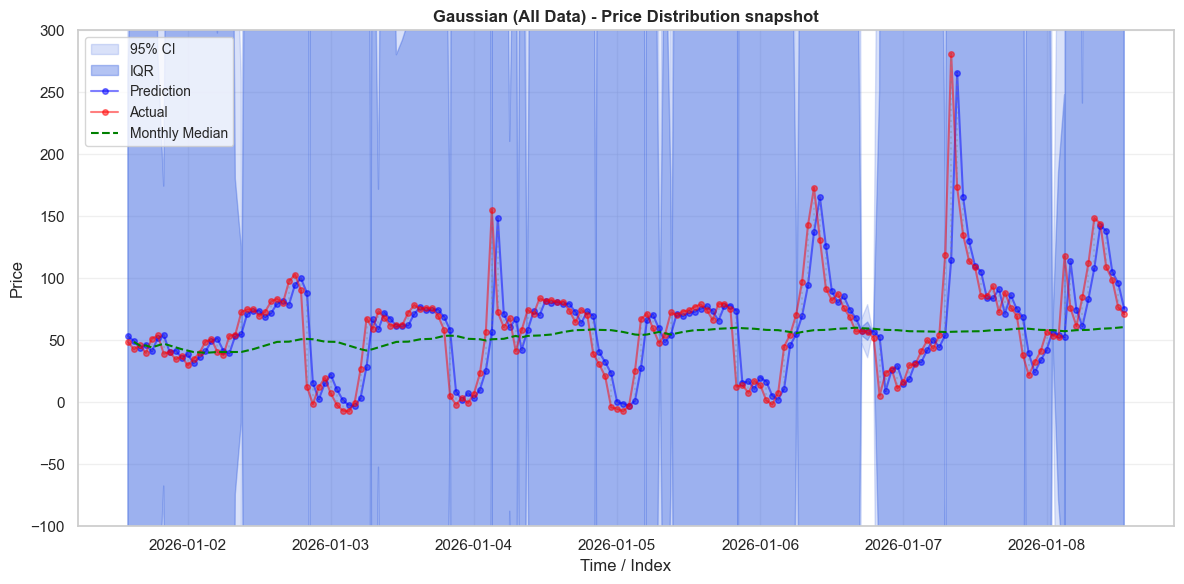

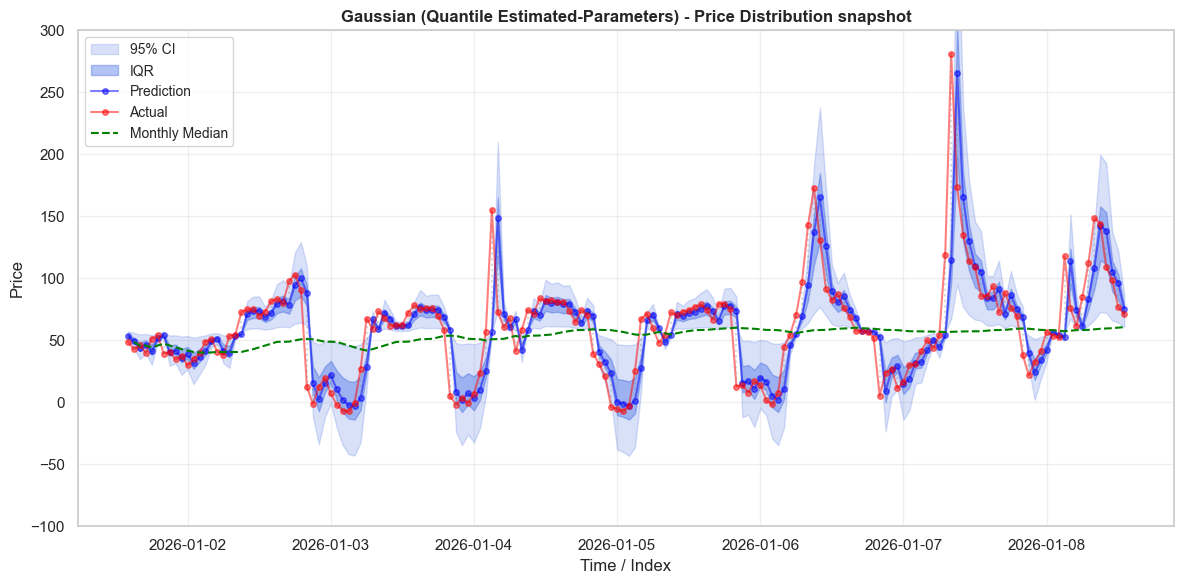

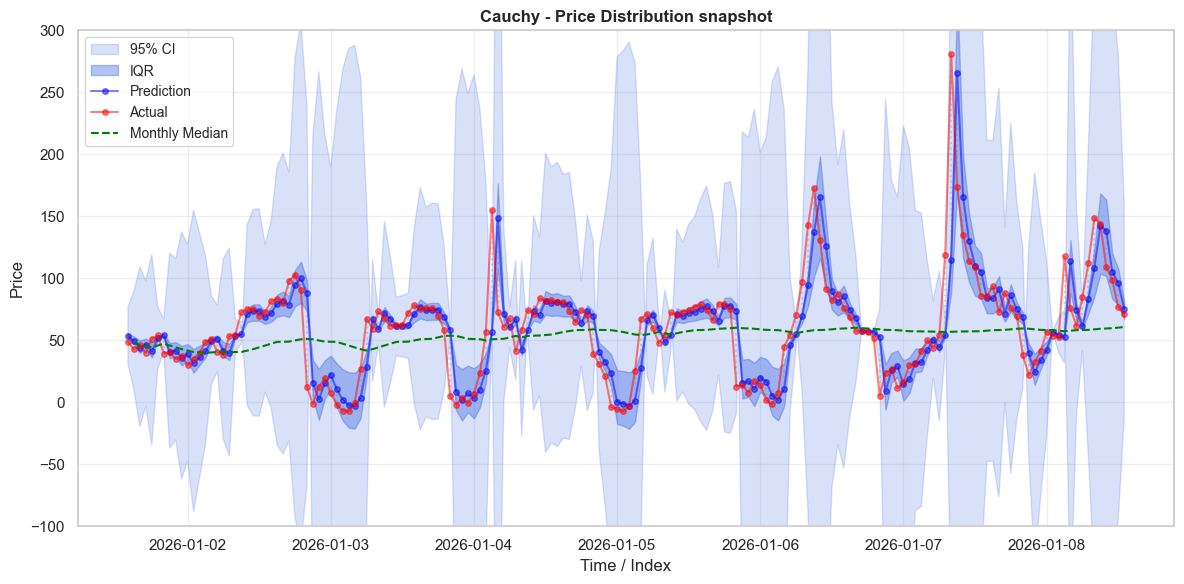

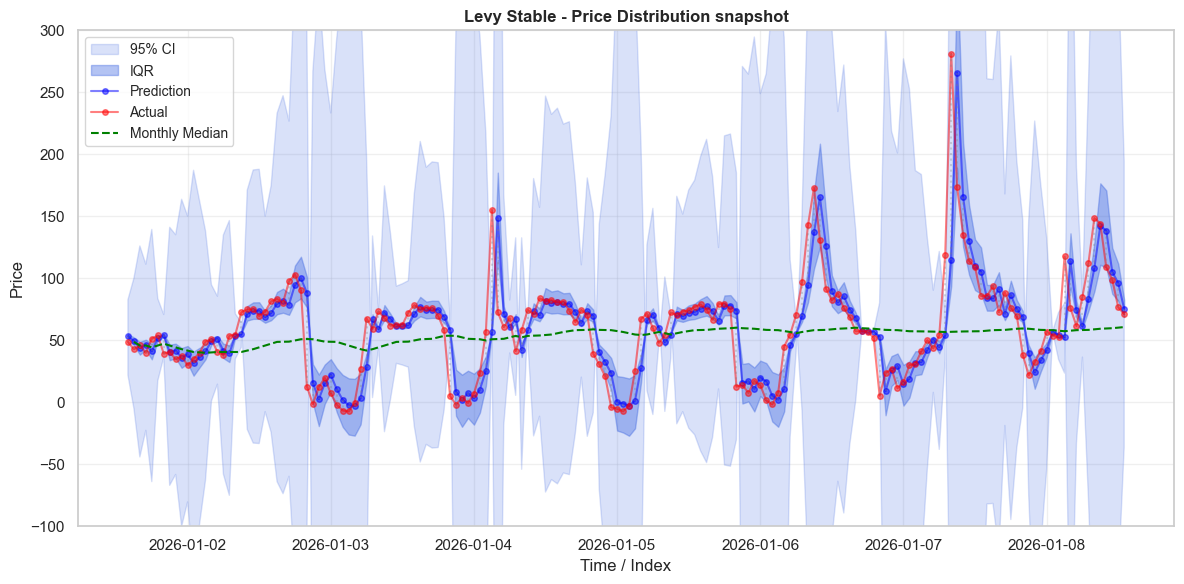

In [55]:
# Import and plot custom ribbon plot
from ribbon_plot import ribbon_plot
num_days=8
# Example usage for one distribution (repeat for others as needed)
for d in distributions:
    ribbon_plot(
        data=test_valid.iloc[(num_days-7)*24:num_days*24],
        x_axis='timestamp',
        predictions='pred',
        actuals='price',
        reversion='reversion',
        dist_params=d,
        monthly_median_func=compute_shifted_monthly_median,
        show_connectors=True,
        title=f"{d.name} - Price Distribution snapshot",
        ylim = (-100, 300)

    )
# You can use test_valid as needed.

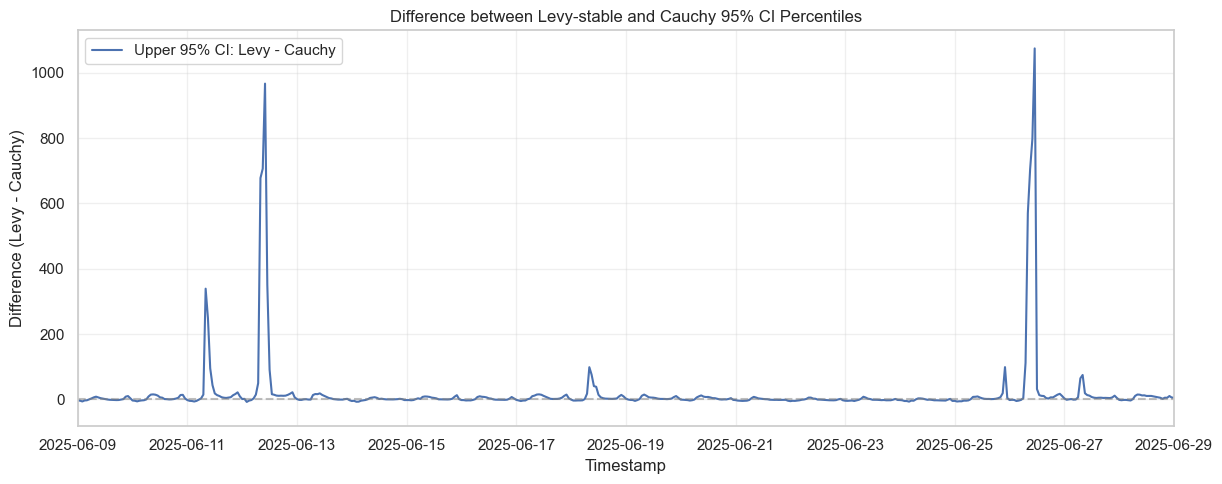

In [50]:
# Plot the differences between Levy-stable and Cauchy 95% CI percentiles
import matplotlib.pyplot as plt

# Get the two distributions
levy = next(d for d in distributions if 'levy' in d.name.lower())
cauchy = next(d for d in distributions if 'cauchy' in d.name.lower())

# Compute 95% CI percentiles for each prediction in train_valid
q_low, q_high = 0.25, 0.75
levy_q = DistributionQuantiles.get_quantiles(levy, [q_low, q_high])
cauchy_q = DistributionQuantiles.get_quantiles(cauchy, [q_low, q_high])

levy_lower = train_valid.pred.values + train_valid.reversion.values * levy_q[0]
levy_upper = train_valid.pred.values + train_valid.reversion.values * levy_q[1]
cauchy_lower = train_valid.pred.values + train_valid.reversion.values * cauchy_q[0]
cauchy_upper = train_valid.pred.values + train_valid.reversion.values * cauchy_q[1]

# Differences
diff_lower = levy_lower - cauchy_lower
diff_upper = levy_upper - cauchy_upper

plt.figure(figsize=(12,5))
# plt.plot(train_valid.timestamp.values, diff_lower, label='Lower 95% CI: Levy - Cauchy')
plt.plot(train_valid.timestamp.values, diff_upper, label='Upper 95% CI: Levy - Cauchy')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Difference between Levy-stable and Cauchy 95% CI Percentiles')
plt.xlabel('Timestamp')
plt.ylabel('Difference (Levy - Cauchy)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Fix: Use pandas Timestamp for xlim indexing
import datetime
plt.xlim(pd.Timestamp('2025-06-09'), pd.Timestamp('2025-06-29'))
plt.show()